# ML Model --- Brain Stroke Data --- Thomas Hughes

---

## * Initial setup *

In [37]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#encoding
from numpy import array
from numpy import argmax
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

#standardisation
from sklearn.preprocessing import StandardScaler

#K-nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [38]:
# import csv
df = pd.read_csv("../Data/brain_stroke_data.csv")

## 1. EDA

In [39]:
# initial check
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [40]:
# shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4482
Number of columns: 11


In [41]:
# datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   Residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB


In [42]:
# assessing the number of nulls
nulls = df.isna().sum().to_frame(name="Number of nulls")
if nulls["Number of nulls"].sum() == 0:
    print("The dataset has no nulls")
display(nulls)

The dataset has no nulls


,Number of nulls
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [43]:
# assessing number of duplicates
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [44]:
# assessing numeric columns
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000
mean,43.446693,0.098394,0.054663,105.761430,28.466064,0.049755
std,22.592327,0.297879,0.227347,44.943627,6.764658,0.217462
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,26.000000,0.000000,0.000000,77.192500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.637500,32.575000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


In [45]:
# assessing gender (ensuring binary either Male or Female)
#print(df.groupby("gender").size())
print(df["gender"].value_counts().to_frame())

print("----------------")

display(
    (pd.crosstab(
        df["gender"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

# investigation of ages below 1.
#display(df[df["age"] < 1])
#(df["age"] < 1).sum()

        count
gender       
Female   2600
Male     1882
----------------


,Stroke %
gender,
Female,5.0
Male,5.0


In [46]:
# assessing hypertension (ensuring binary either 0 or 1)
print(df["hypertension"].value_counts().to_frame())

print("---------------------")

display(
    (pd.crosstab(
        df["hypertension"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

              count
hypertension       
0              4041
1               441
---------------------


,Stroke %
hypertension,
0,4.0
1,13.0


In [47]:
# assessing heart_disease (ensuring binary either 0 or 1)
print(df["heart_disease"].value_counts().to_frame())

print("---------------------")

display(
    (pd.crosstab(
        df["heart_disease"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

               count
heart_disease       
0               4237
1                245
---------------------


,Stroke %
heart_disease,
0,4.0
1,17.0


In [48]:
# assessing ever_married (ensuring binary either Yes or No)
print(df["ever_married"].value_counts().to_frame())

print("---------------------")

display(
    (pd.crosstab(
        df["ever_married"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

              count
ever_married       
Yes            2951
No             1531
---------------------


,Stroke %
ever_married,
No,2.0
Yes,7.0


In [49]:
# assessing work_type (ensuring valid categories -> Private, Self-employed, children, Gov_job)
print(df["work_type"].value_counts().to_frame())

print("----------------------")

display(
    (pd.crosstab(
        df["work_type"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

               count
work_type           
Private         2571
Self-employed    721
children         602
Govt_job         588
----------------------


,Stroke %
work_type,
Govt_job,5.0
Private,5.0
Self-employed,8.0
children,0.0


In [50]:
# assessing Residence_type (ensuring binary either Urban or Rural)
print(df["Residence_type"].value_counts().to_frame())

print("-----------------------")

display(
    (pd.crosstab(
        df["Residence_type"],
        df["stroke"],
        normalize="index"
    ) * 100)
    .round(0)[1]
    .to_frame(name="Stroke %")
)

                count
Residence_type       
Urban            2282
Rural            2200
-----------------------


,Stroke %
Residence_type,
Rural,5.0
Urban,5.0


In [51]:
# assessing smoking_status (ensuring valid categories -> never smoked, Unknown, formerly smoked, smokes)
print(df["smoking_status"].value_counts().to_frame())
print("----------------------")

unknown_percent = ((1352/df.shape[0])*100)
print("Percentage of 'Unknown' in smoking_status:", int(unknown_percent), '%')

# does 'Unknown' category vary from others with stroke percentage? does it hold information?
display((pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    normalize="index"
) * 100).round(1))

                 count
smoking_status        
never smoked      1665
Unknown           1352
formerly smoked    759
smokes             706
----------------------
Percentage of 'Unknown' in smoking_status: 30 %


stroke,0,1
smoking_status,,
Unknown,96.8,3.2
formerly smoked,91.8,8.2
never smoked,95.3,4.7
smokes,94.5,5.5


In [52]:
# assessing stroke (ensuring binary either 0 or 1)
print(df["stroke"].value_counts())

stroke
0    4259
1     223
Name: count, dtype: int64


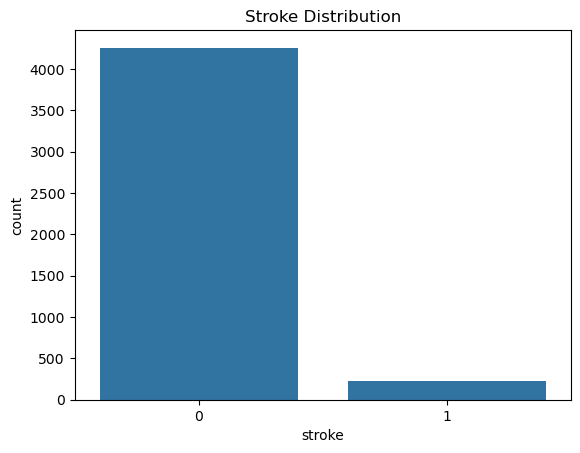

Percentage of patients who didn't have a stroke (0): 95.0
Percentage of patients who had a stroke (1): 5.0


In [53]:
# count plot of target variable
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()
print("Percentage of patients who didn't have a stroke (0):", ((df["stroke"].value_counts()[0]/df.shape[0])*100).round(1))
print("Percentage of patients who had a stroke (1):", ((df["stroke"].value_counts()[1]/df.shape[0])*100).round(1))

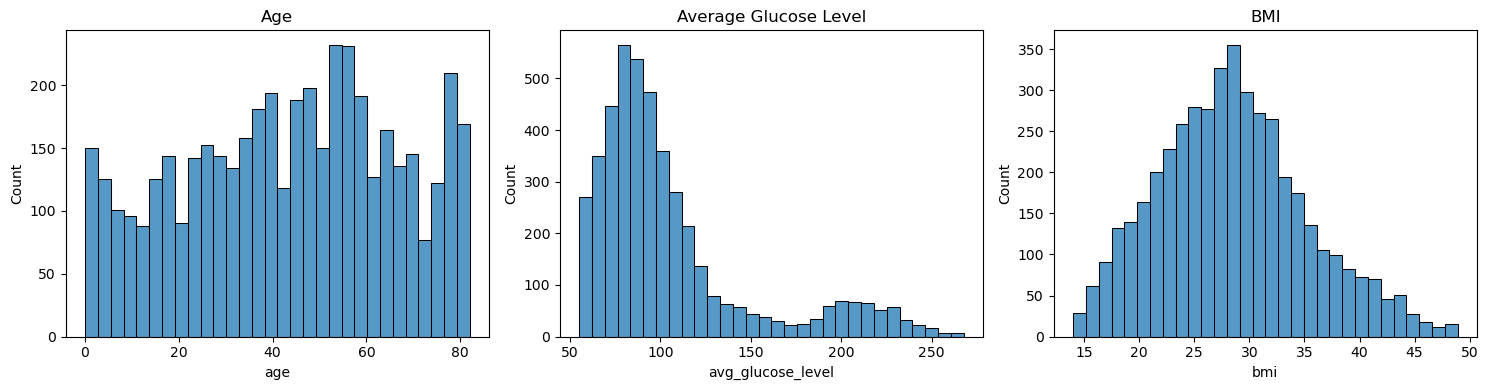

In [54]:
# analysing distribution of continuous variables

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["age"], bins=30, ax=axes[0])
axes[0].set_title("Age")

sns.histplot(df["avg_glucose_level"], bins=30, ax=axes[1])
axes[1].set_title("Average Glucose Level")

sns.histplot(df["bmi"], bins=30, ax=axes[2])
axes[2].set_title("BMI")

plt.tight_layout()
plt.show()

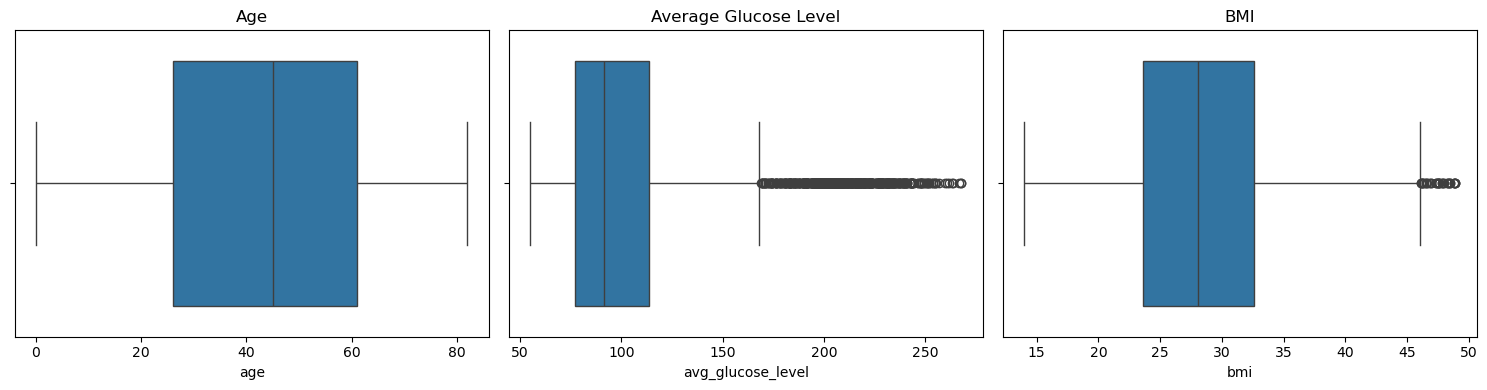

In [55]:
# analysing outliers

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(x=df["age"], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(x=df["avg_glucose_level"], ax=axes[1])
axes[1].set_title("Average Glucose Level")

sns.boxplot(x=df["bmi"], ax=axes[2])
axes[2].set_title("BMI")

plt.tight_layout()
plt.show()

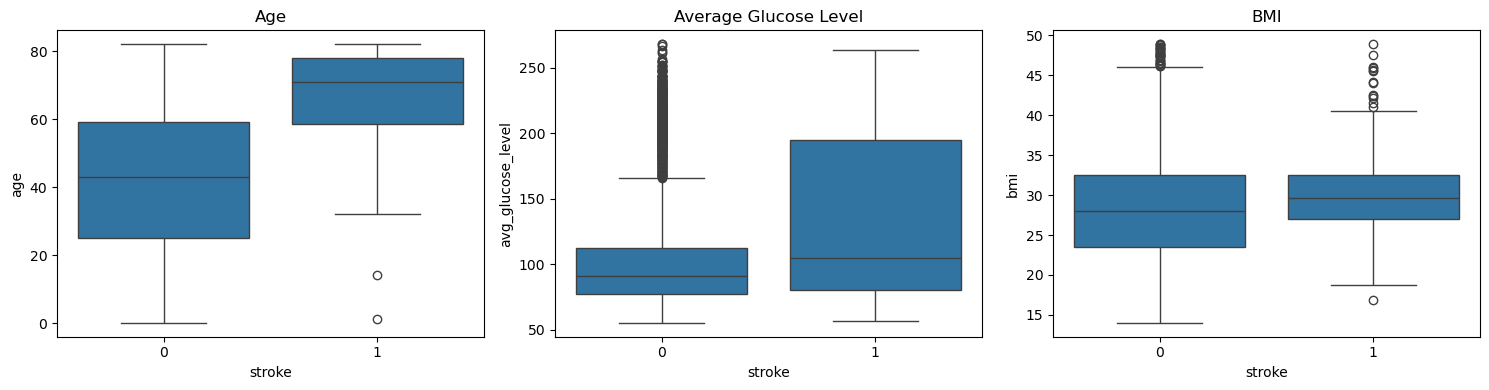

In [56]:
# analysing stroke distribution vs. continuous variables distribution

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(x="stroke", y="age", data=df, ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(x="stroke", y="avg_glucose_level", data=df, ax=axes[1])
axes[1].set_title("Average Glucose Level")

sns.boxplot(x="stroke", y="bmi", data=df, ax=axes[2])
axes[2].set_title("BMI")

plt.tight_layout()
plt.show()

## Report of section 1. EDA
The dataset has no nulls

The dataset has no duplicated rows

All datatypes look consistent. 'object' for string types, 'int64' for binary values, and 'float64' for continuous numeric values.

for each column: 
 - gender: Binary, either male or female. male and female have the same stroke% prevalence (5%)
 - age: Min = 0.08, max = 82, no negative values or impossible ages. ~ evenely distributed, with slight concerntration around 40-80 years old. Strong relationship between stroke and higher age. Median age for non-stroke ~40, median age for stroke ~70
 - hypertension: Binary, either 0 (doesn't have hypertension) or 1 (has hypertension). hypertension has a higher stroke% (13% compared to 4%).
 - heart_disease: Binary, either 0 (doesn't have heart disease) or 1 (has heart disease). heart_disease has a higher stroke% (17% compared to 4%)
 - ever_married: Binary, either Yes or No. married has a higher stroke% (7% compared to 2%)
 - work_type: Valid categories -> Private, Self-employed, children, Gov_job. children have 0% stroke prevalence, self-employed have the highest stroke% (8%)
 - Residence_type: Binary, either Urban or Rural. Urban and rural have the same stroke% prevalence (5%)
 - avg_glucose_level: Min = 55.12, max = 267.76, no negative values or impossible glucose levels. Right skew, with most values ~80, with a long tail and small spike around 200. Strong relationship between stroke and higher glucose level. Wider distribution of higher glucose levels with patients with stroke.
 - bmi: Min = 14, max = 48.9, no negative values of impossible BMIs. Roughly a bell shaped distribution. weak relationship with stroke and bmi.
 - smoking_status: 'Unknown' category makes up 30% of the total data, and reflects genuine missing data (stated on Kaggle). The percentage of stroke patients within the 'Unknown' category is 3%, which differs from 'formely smoked' (8.2%), 'never smoked' (4.7%), 'smokes' (5.5%). This implies that the 'Unknown' category holds information and doesnt behave like the others categories, therefore 'Unknown' was kept and not changed.
 - stroke: Binary, either 0 (didn't have a stroke) or 1 (had a stroke). Unbalanced target variable: 95% = 0, 5% = 1. This requires balancing.

## 2. Split features, test/train split

In [57]:
# splitting into X (all columns except stroke) and Y (stroke column)
X = df.drop(columns="stroke")
y = df["stroke"]

# splitting data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,    # picks 20%
    random_state=42,   # shuffles data randomly
    stratify=y,        # stratify ensures that the train and test sets have the same proportion of classes as the original dataset
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

print("\nClass balance in training data:")
print(y_train.value_counts(normalize=True).round(2))

print("\nClass balance in test data:")
print(Y_test.value_counts(normalize=True).round(2))

Training features: (3585, 10)
Test features: (897, 10)
Training target: (3585,)
Test target: (897,)

Class balance in training data:
stroke
0    0.95
1    0.05
Name: proportion, dtype: float64

Class balance in test data:
stroke
0    0.95
1    0.05
Name: proportion, dtype: float64


## 3. Encoding

In [58]:
#categorical data encoding:

#gender -> no natural order -> binary coding
#ever_married -> no natural order -> binary coding
#work_type -> no natural order -> One-Hot Encoding
#Residence_type -> no natural order -> binary coding
#smoking_status -> no natural order -> One-Hot Encoding

# binary coding: gender, ever_married, Residence_type

X_train["gender"] = X_train["gender"].map({"Female": 0, "Male": 1})
X_test["gender"] = X_test["gender"].map({"Female": 0, "Male": 1})

X_train["ever_married"] = X_train["ever_married"].map({"No": 0, "Yes": 1})
X_test["ever_married"] = X_test["ever_married"].map({"No": 0, "Yes": 1})

X_train["Residence_type"] = X_train["Residence_type"].map({"Rural": 0, "Urban": 1})
X_test["Residence_type"] = X_test["Residence_type"].map({"Rural": 0, "Urban": 1})

# one-hot encoding: work_type, smoking_status

# create encoder
encoder = OneHotEncoder(sparse_output=False)

# encode train and test data
train_encoded = encoder.fit_transform(X_train[["work_type", "smoking_status"]])
test_encoded = encoder.transform(X_test[["work_type", "smoking_status"]])

# create new dfs of encoded values
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(),
    index=X_test.index
)

# drop original columns
X_train = X_train.drop(columns=["work_type", "smoking_status"])
X_test = X_test.drop(columns=["work_type", "smoking_status"])

# add encoded columns
X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)


In [59]:
display(X_train.head(3))
display(X_test.head(3))

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3319,0,53.0,0,0,1,0,102.00,32.4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1468,1,52.0,0,0,1,0,67.92,31.1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
97,0,37.0,0,0,0,0,77.37,21.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
537,1,9.0,0,0,0,1,114.99,18.8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
642,0,67.0,0,0,1,0,81.68,30.4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1916,1,20.0,0,0,0,0,98.70,26.2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 4. Standardisation

In [60]:
# collect numerical columns which require standardisation
numerical_cols = ["age", "avg_glucose_level", "bmi"]

scaler = StandardScaler()

# fit AND trasform training data first. This 'fit' learns the stats for training data
X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

# ONLY transform test data (using 'fit' stats from training)
X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [62]:
# checks
X_train[numerical_cols].describe()

,age,avg_glucose_level,bmi
count,3.585000e+03,3.585000e+03,3.585000e+03
mean,4.954970e-17,6.936958e-17,3.389200e-16
std,1.000139e+00,1.000139e+00,1.000139e+00
min,-1.913035e+00,-1.134852e+00,-2.113656e+00
25%,-8.110809e-01,-6.410435e-01,-7.258218e-01
50%,7.331265e-02,-3.198581e-01,-6.143305e-02
75%,7.808275e-01,1.876368e-01,6.029557e-01
max,1.709441e+00,3.559090e+00,3.024284e+00


In [61]:
# checks
display(X_train)
display(X_test)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3319,0,0.427070,0,0,1,0,-0.099995,0.588192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1468,1,0.382850,0,0,1,0,-0.852297,0.396257,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
97,0,-0.280445,0,0,0,0,-0.643692,-1.035870,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2774,1,0.382850,0,0,1,0,-0.842805,0.839183,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
999,1,-0.413104,0,0,1,1,0.951197,1.621685,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0,-0.545763,0,0,1,0,-0.786294,-0.017140,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2386,0,-0.368884,0,0,0,1,-0.197565,-0.607708,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1360,0,1.621001,0,0,1,0,-0.682323,-0.489595,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3210,0,-0.015127,0,0,0,1,-0.767310,-0.223839,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
537,1,-1.518596,0,0,0,1,0.186754,-1.419739,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
642,0,1.046146,0,0,1,0,-0.548551,0.292908,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1916,1,-1.032179,0,0,0,0,-0.172841,-0.327189,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1001,1,-1.877660,0,0,0,1,0.124945,-1.404975,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3255,1,-0.943740,0,0,0,0,-0.462681,-0.622472,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3141,0,-0.987960,0,0,1,1,0.437521,-0.223839,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3853,0,-0.589983,0,0,1,1,-0.995120,1.223052,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3234,0,1.355683,0,0,1,1,0.209932,0.366729,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1465,0,-1.209058,0,0,0,0,-0.419194,1.385458,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 5. Sampling

In [ ]:
# sampling SMOTE
# over sample and undersample